In [4]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv("/content/drive/MyDrive/AI-Powered-Supply-Chain-Analytics/data/processed/DataCoSupplyChainDataset_FeatureEngineered.csv")

In [6]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,shipping date (DateOrders),Shipping Mode,Shipping Delay,Order Month,Order Month Number,Order Quarter,Order Year,Order Day,Day Type,Profit Margin
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,2018-02-03 22:56:00,Standard Class,-1,January,1,1,2018,Wednesday,Weekday,27.841342
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,2018-01-18 12:27:00,Standard Class,1,January,1,1,2018,Saturday,Weekend,-75.999999
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,2018-01-17 12:06:00,Standard Class,0,January,1,1,2018,Saturday,Weekend,-75.600305
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,2018-01-16 11:45:00,Standard Class,-1,January,1,1,2018,Saturday,Weekend,6.974829
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,2018-01-15 11:24:00,Standard Class,-2,January,1,1,2018,Saturday,Weekend,40.948896


In [7]:
df.shape

(180519, 54)

In [8]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Id', 'Customer Segment', 'Customer State',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product Description', 'Product Name', 'Product Price',
       'Product Status', 'shipping date (DateOrders)', 'Shipping Mode',
       'Shi

In [9]:
y = df["Late_delivery_risk"]

In [10]:
y.head()

,Late_delivery_risk
0,0
1,1
2,0
3,0
4,0


In [31]:
columns_to_drop = [
    # Target
    "Late_delivery_risk",

    # Data Leakage
    "Delivery Status",
    "Shipping Delay",
    "Days for shipping (real)",
    "Order Status",
    "order date (DateOrders)",
    "shipping date (DateOrders)",

    # IDs
    "Order Id",
    "Customer Id",
    "Order Customer Id",
    "Order Item Id",
    "Order Item Cardprod Id",
    "Product Card Id",
    "Product Category Id",
    "Category Id",
    "Department Id",

    # Geographic coordinates
    "Latitude",
    "Longitude",

    # High-cardinality text columns
    "Product Name",
    "Product Description",
    "Customer City",
    "Customer State",
    "Order City",
    "Order State",
    "Order Country"
]

In [32]:
X = df.drop(columns=columns_to_drop)

In [33]:
X.head()

,Type,Days for shipment (scheduled),Benefit per order,Sales per customer,Category Name,Customer Country,Customer Segment,Department Name,Market,Order Item Discount,...,Product Price,Product Status,Shipping Mode,Order Month,Order Month Number,Order Quarter,Order Year,Order Day,Day Type,Profit Margin
0,DEBIT,4,91.250000,314.640015,Sporting Goods,Puerto Rico,Consumer,Fitness,Pacific Asia,13.110000,...,327.75,0,Standard Class,January,1,1,2018,Wednesday,Weekday,27.841342
1,TRANSFER,4,-249.089996,311.359985,Sporting Goods,Puerto Rico,Consumer,Fitness,Pacific Asia,16.389999,...,327.75,0,Standard Class,January,1,1,2018,Saturday,Weekend,-75.999999
2,CASH,4,-247.779999,309.720001,Sporting Goods,EE. UU.,Consumer,Fitness,Pacific Asia,18.030001,...,327.75,0,Standard Class,January,1,1,2018,Saturday,Weekend,-75.600305
3,DEBIT,4,22.860001,304.809998,Sporting Goods,EE. UU.,Home Office,Fitness,Pacific Asia,22.940001,...,327.75,0,Standard Class,January,1,1,2018,Saturday,Weekend,6.974829
4,PAYMENT,4,134.210007,298.250000,Sporting Goods,Puerto Rico,Corporate,Fitness,Pacific Asia,29.500000,...,327.75,0,Standard Class,January,1,1,2018,Saturday,Weekend,40.948896


In [34]:
X.shape

(180519, 29)

In [35]:
X.columns

Index(['Type', 'Days for shipment (scheduled)', 'Benefit per order',
       'Sales per customer', 'Category Name', 'Customer Country',
       'Customer Segment', 'Department Name', 'Market', 'Order Item Discount',
       'Order Item Discount Rate', 'Order Item Product Price',
       'Order Item Profit Ratio', 'Order Item Quantity', 'Sales',
       'Order Item Total', 'Order Profit Per Order', 'Order Region',
       'Order Zipcode', 'Product Price', 'Product Status', 'Shipping Mode',
       'Order Month', 'Order Month Number', 'Order Quarter', 'Order Year',
       'Order Day', 'Day Type', 'Profit Margin'],
      dtype='object')

###one hot encoding

In [36]:
X.select_dtypes(include="object").nunique().sort_values()

,0
Customer Country,2
Day Type,2
Customer Segment,3
Type,4
Shipping Mode,4
Market,5
Order Day,7
Department Name,11
Order Month,12
Order Region,23


In [37]:
categorical_columns = X.select_dtypes(include="object").columns

categorical_columns

Index(['Type', 'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'Market', 'Order Region', 'Shipping Mode',
       'Order Month', 'Order Day', 'Day Type'],
      dtype='object')

In [38]:
X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

In [40]:
X.shape

(180519, 130)

In [41]:
X.head()

,Days for shipment (scheduled),Benefit per order,Sales per customer,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,...,Order Month_November,Order Month_October,Order Month_September,Order Day_Monday,Order Day_Saturday,Order Day_Sunday,Order Day_Thursday,Order Day_Tuesday,Order Day_Wednesday,Day Type_Weekend
0,4,91.250000,314.640015,13.110000,0.04,327.75,0.29,1,327.75,314.640015,...,0,0,0,0,0,0,0,0,1,0
1,4,-249.089996,311.359985,16.389999,0.05,327.75,-0.80,1,327.75,311.359985,...,0,0,0,0,1,0,0,0,0,1
2,4,-247.779999,309.720001,18.030001,0.06,327.75,-0.80,1,327.75,309.720001,...,0,0,0,0,1,0,0,0,0,1
3,4,22.860001,304.809998,22.940001,0.07,327.75,0.08,1,327.75,304.809998,...,0,0,0,0,1,0,0,0,0,1
4,4,134.210007,298.250000,29.500000,0.09,327.75,0.45,1,327.75,298.250000,...,0,0,0,0,1,0,0,0,0,1


In [42]:
X.select_dtypes(include="object").columns

Index([], dtype='object')

In [44]:
print(X.columns.tolist())

['Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Zipcode', 'Product Price', 'Product Status', 'Order Month Number', 'Order Quarter', 'Order Year', 'Profit Margin', 'Type_DEBIT', 'Type_PAYMENT', 'Type_TRANSFER', 'Category Name_As Seen on  TV!', 'Category Name_Baby ', 'Category Name_Baseball & Softball', 'Category Name_Basketball', 'Category Name_Books ', 'Category Name_Boxing & MMA', 'Category Name_CDs ', 'Category Name_Cameras ', 'Category Name_Camping & Hiking', 'Category Name_Cardio Equipment', "Category Name_Children's Clothing", 'Category Name_Cleats', 'Category Name_Computers', 'Category Name_Consumer Electronics', 'Category Name_Crafts', 'Category Name_DVDs', 'Category Name_Electronics', 'Category Name_Fishing', 'Category Name_Fitness Accessories', 'Category Name_G

In [46]:
X.dtypes

,0
Days for shipment (scheduled),int64
Benefit per order,float64
Sales per customer,float64
Order Item Discount,float64
Order Item Discount Rate,float64
...,...
Order Day_Sunday,int64
Order Day_Thursday,int64
Order Day_Tuesday,int64
Order Day_Wednesday,int64


In [47]:
X.head()

,Days for shipment (scheduled),Benefit per order,Sales per customer,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,...,Order Month_November,Order Month_October,Order Month_September,Order Day_Monday,Order Day_Saturday,Order Day_Sunday,Order Day_Thursday,Order Day_Tuesday,Order Day_Wednesday,Day Type_Weekend
0,4,91.250000,314.640015,13.110000,0.04,327.75,0.29,1,327.75,314.640015,...,0,0,0,0,0,0,0,0,1,0
1,4,-249.089996,311.359985,16.389999,0.05,327.75,-0.80,1,327.75,311.359985,...,0,0,0,0,1,0,0,0,0,1
2,4,-247.779999,309.720001,18.030001,0.06,327.75,-0.80,1,327.75,309.720001,...,0,0,0,0,1,0,0,0,0,1
3,4,22.860001,304.809998,22.940001,0.07,327.75,0.08,1,327.75,304.809998,...,0,0,0,0,1,0,0,0,0,1
4,4,134.210007,298.250000,29.500000,0.09,327.75,0.45,1,327.75,298.250000,...,0,0,0,0,1,0,0,0,0,1


In [49]:
X.select_dtypes(include="object").columns

Index([], dtype='object')

In [50]:
X.shape

(180519, 130)

###Train-Test Split

In [51]:
from sklearn.model_selection import train_test_split

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [53]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (144415, 130)
X_test : (36104, 130)
y_train: (144415,)
y_test : (36104,)


###Model Building: Logistic regression

In [54]:
from sklearn.linear_model import LogisticRegression

In [55]:
log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [57]:
missing = X_train.isnull().sum()
missing[missing > 0]

,0
Order Zipcode,124503


In [58]:
X_train.isnull().sum().sum()

np.int64(124503)

In [59]:
X_train = X_train.drop(columns=["Order Zipcode"])
X_test = X_test.drop(columns=["Order Zipcode"])

In [60]:
X_train.isnull().sum().sum()

np.int64(0)

In [61]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_reg.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

In [62]:
from sklearn.preprocessing import StandardScaler

In [63]:
scaler = StandardScaler()

In [64]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [65]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [66]:
y_pred = log_reg.predict(X_test_scaled)

###Model Evaluation

In [67]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [68]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6957677819632174


In [69]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[14236  2072]
 [ 8912 10884]]


In [70]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.87      0.72     16308
           1       0.84      0.55      0.66     19796

    accuracy                           0.70     36104
   macro avg       0.73      0.71      0.69     36104
weighted avg       0.74      0.70      0.69     36104



In [71]:
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

ROC-AUC Score: 0.7413199780017647


###Model Building:Decision tree

In [72]:
from sklearn.tree import DecisionTreeClassifier

In [73]:
dt = DecisionTreeClassifier(
    random_state=42
)

In [74]:
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [75]:
y_pred_dt = dt.predict(X_test)

In [76]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

y_prob_dt = dt.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))

Accuracy: 0.6284622202526036

Confusion Matrix:
[[ 9503  6805]
 [ 6609 13187]]

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.58      0.59     16308
           1       0.66      0.67      0.66     19796

    accuracy                           0.63     36104
   macro avg       0.62      0.62      0.62     36104
weighted avg       0.63      0.63      0.63     36104

ROC-AUC: 0.6244413709064739


###Model Building: Random Forest

In [77]:
from sklearn.ensemble import RandomForestClassifier

In [78]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [79]:
rf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [81]:
y_pred_rf = rf.predict(X_test)

In [82]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.6959339685353424

Confusion Matrix:
[[12817  3491]
 [ 7487 12309]]

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.79      0.70     16308
           1       0.78      0.62      0.69     19796

    accuracy                           0.70     36104
   macro avg       0.71      0.70      0.70     36104
weighted avg       0.71      0.70      0.70     36104

ROC-AUC: 0.7573674616977399


In [83]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

In [84]:
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, min_samples_leaf=5, min_samples_split=10,
                       n_estimators=200, n_jobs=-1, random_state=42)

In [85]:
y_pred_rf = rf.predict(X_test)

In [86]:
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [87]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.7012242410813206

Confusion Matrix:
[[13988  2320]
 [ 8467 11329]]

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.86      0.72     16308
           1       0.83      0.57      0.68     19796

    accuracy                           0.70     36104
   macro avg       0.73      0.72      0.70     36104
weighted avg       0.74      0.70      0.70     36104

ROC-AUC: 0.7554338561643703


###Feature Importance

In [88]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
0,Days for shipment (scheduled),0.278219
110,Shipping Mode_Standard Class,0.249167
109,Shipping Mode_Second Class,0.052731
108,Shipping Mode_Same Day,0.036485
16,Profit Margin,0.028666
1,Benefit per order,0.027751
10,Order Profit Per Order,0.027582
9,Order Item Total,0.022848
2,Sales per customer,0.022848
3,Order Item Discount,0.022526


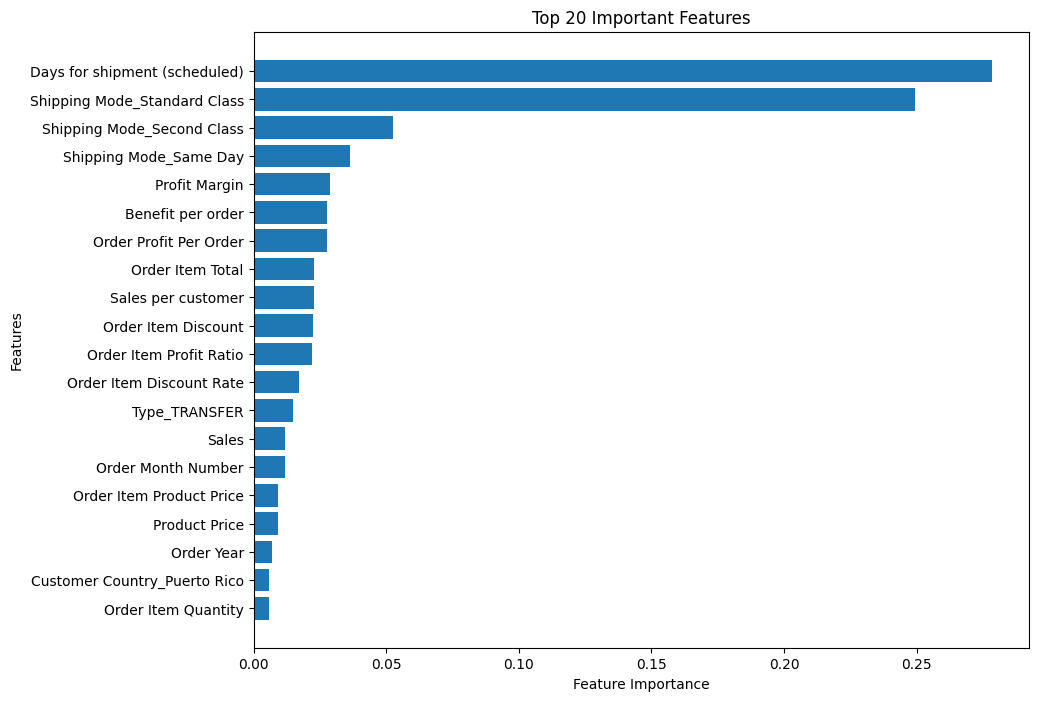

In [89]:
import matplotlib.pyplot as plt

top20 = feature_importance.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 20 Important Features")

plt.gca().invert_yaxis()

plt.show()

In [90]:
import joblib

joblib.dump(rf, "random_forest_model.pkl")

['random_forest_model.pkl']

In [91]:
import os

os.path.exists("random_forest_model.pkl")

True

### load model with
model = joblib.load("random_forest_model.pkl")

Conclusion

This project developed a machine learning model to predict whether an order would be delivered late using the DataCo Supply Chain dataset.

The workflow included data cleaning, exploratory data analysis, feature engineering, feature selection, handling missing values, one-hot encoding, train-test splitting, feature scaling where appropriate, and training multiple classification models.

Three models were evaluated:

Logistic Regression

Decision Tree

Random Forest


Random Forest achieved the strongest overall performance and was selected as the final model because it provided the best balance between accuracy, F1-score, and ROC-AUC.

The feature importance analysis identified the most influential variables affecting late deliveries, providing useful business insights for logistics planning and supply chain optimization.

This predictive model can help organizations identify high-risk orders in advance, improve shipment prioritization, reduce delivery delays, and enhance customer satisfaction.